In [20]:
# 1. INSTALL & IMPORT DEPENDENCIES
# !pip install yfinance pandas scikit-learn matplotlib

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
import pickle

In [21]:
# 2. DATA ACQUISITION (Live from yfinance)
# Tickers: Gold, S&P 500, VIX, Oil, Silver, EUR/USD

tickers = ['GC=F', '^GSPC', '^VIX', 'USO', 'SLV', 'EURUSD=X']

print("Fetching historical market data (2000 - Present)...")

# Download the 'Close' price for all assets
raw_data = yf.download(tickers, start="2000-01-01", interval="1d")['Close']

Fetching historical market data (2000 - Present)...


[*********************100%***********************]  6 of 6 completed


In [22]:
# 3. DATA CLEANING & FEATURE MAPPING
# yfinance returns columns in alphabetical order by ticker
# Mapping: EURUSD=X -> EURUSD, GC=F -> GLD, SLV -> SLV, USO -> USO, ^GSPC -> SPX, ^VIX -> VIX

df = raw_data.copy()
df.columns = ['EURUSD', 'GLD', 'SLV', 'USO', 'SPX', 'VIX']

# Drop missing values (weekends/holidays when some markets are closed)
df = df.dropna()

print(f"Data processed. Total training samples: {len(df)}")
print(df.head())

Data processed. Total training samples: 5009
              EURUSD         GLD     SLV         USO          SPX    VIX
Date                                                                    
2006-04-28  1.263600  651.799988  13.812  556.960022  1310.609985  11.59
2006-05-01  1.258004  657.500000  13.870  572.000000  1305.189941  12.54
2006-05-02  1.261702  664.700012  14.365  578.719971  1313.209961  11.99
2006-05-03  1.262307  665.900024  13.925  561.760010  1308.119995  11.99
2006-05-04  1.270099  674.200012  14.000  546.559998  1312.250000  11.86


In [23]:
# Checking last data in the dataset.
print(df.tail())

              EURUSD          GLD        SLV         USO          SPX  \
Date                                                                    
2026-05-07  1.174743  4699.799805  71.599998  134.970001  7337.109863   
2026-05-08  1.173158  4720.399902  73.010002  133.589996  7398.930176   
2026-05-11  1.176886  4718.700195  78.000000  138.660004  7412.839844   
2026-05-12  1.177995  4677.600098  78.550003  144.300003  7400.959961   
2026-05-13  1.171509  4693.000000  79.940102  144.009995  7413.930176   

                  VIX  
Date                   
2026-05-07  17.080000  
2026-05-08  17.190001  
2026-05-11  18.379999  
2026-05-12  17.990000  
2026-05-13  18.030001  


In [24]:
df.shape

(5009, 6)

In [25]:
# Checking the informatiaon of the dataset

df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 5009 entries, 2006-04-28 to 2026-05-13
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   EURUSD  5009 non-null   float64
 1   GLD     5009 non-null   float64
 2   SLV     5009 non-null   float64
 3   USO     5009 non-null   float64
 4   SPX     5009 non-null   float64
 5   VIX     5009 non-null   float64
dtypes: float64(6)
memory usage: 273.9 KB


In [26]:
# Checking if there any null values in the dataset after cleaning.

df.isnull().sum()

EURUSD    0
GLD       0
SLV       0
USO       0
SPX       0
VIX       0
dtype: int64

In [27]:
# statistical data about dataset

df.describe()

,EURUSD,GLD,SLV,USO,SPX,VIX
count,5009.000000,5009.000000,5009.000000,5009.000000,5009.000000,5009.000000
mean,1.222278,1565.953063,21.337381,200.096438,2708.779390,19.589589
std,0.132898,763.015458,10.356965,166.514320,1597.654300,8.711044
min,0.959619,562.000000,8.850000,17.040001,676.530029,9.140000
25%,1.111321,1189.099976,15.280000,75.489998,1395.410034,13.880000
50%,1.182984,1337.000000,18.209999,111.919998,2108.949951,17.250000
75%,1.328304,1792.300049,24.230000,292.880005,3855.929932,22.549999
max,1.598798,5318.399902,105.599998,939.840027,7413.930176,82.690002


In [28]:
# 4. TRAIN/TEST SPLIT
# X = Market Features | Y = Gold Price (GLD)

X = df[['SPX', 'VIX', 'USO', 'SLV', 'EURUSD']]
Y = df['GLD']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [29]:
# 5. MODEL TRAINING (Optimized for Web)

model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)

print("Training Random Forest Regressor...")
model.fit(X_train, Y_train)

Training Random Forest Regressor...


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 


--- Model Performance ---
R-Squared (Accuracy): 0.9973
Mean Absolute Error: $24.94


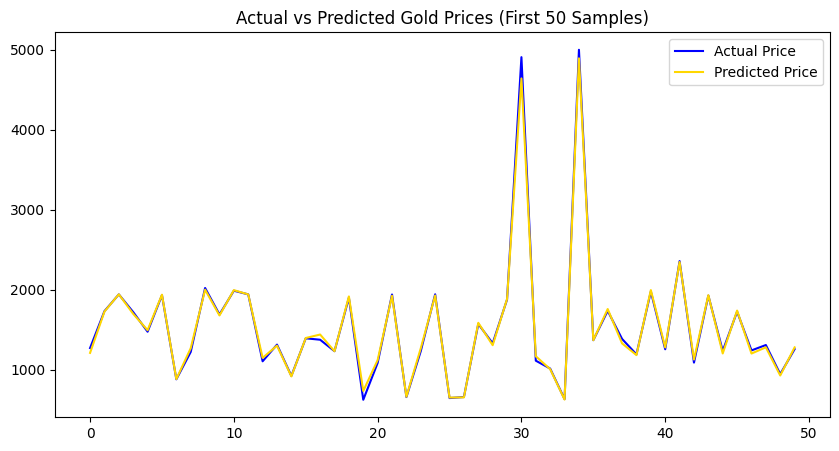

In [30]:
# 6. EVALUATION

predictions = model.predict(X_test)
score = metrics.r2_score(Y_test, predictions)
mae = metrics.mean_absolute_error(Y_test, predictions)

print(f"\n--- Model Performance ---")
print(f"R-Squared (Accuracy): {score:.4f}")
print(f"Mean Absolute Error: ${mae:.2f}")

# Visualizing results
plt.figure(figsize=(10,5))
plt.plot(list(Y_test)[:50], color='blue', label='Actual Price')
plt.plot(predictions[:50], color='gold', label='Predicted Price')
plt.title('Actual vs Predicted Gold Prices (First 50 Samples)')
plt.legend()
plt.show()

In [31]:
# 7. EXPORTING THE BRAIN

filename = 'gold_model.pkl'
pickle.dump(model, open(filename, 'wb'))
print(f"\n Success! '{filename}' has been generated without using any CSV files.")


 Success! 'gold_model.pkl' has been generated without using any CSV files.
